=== Unmatched files by experiment (category could not be determined) ===
- MSK epoch 1: none
- MSK epoch 2: none
- MSK epoch 3: none
- MSK epoch 4: none


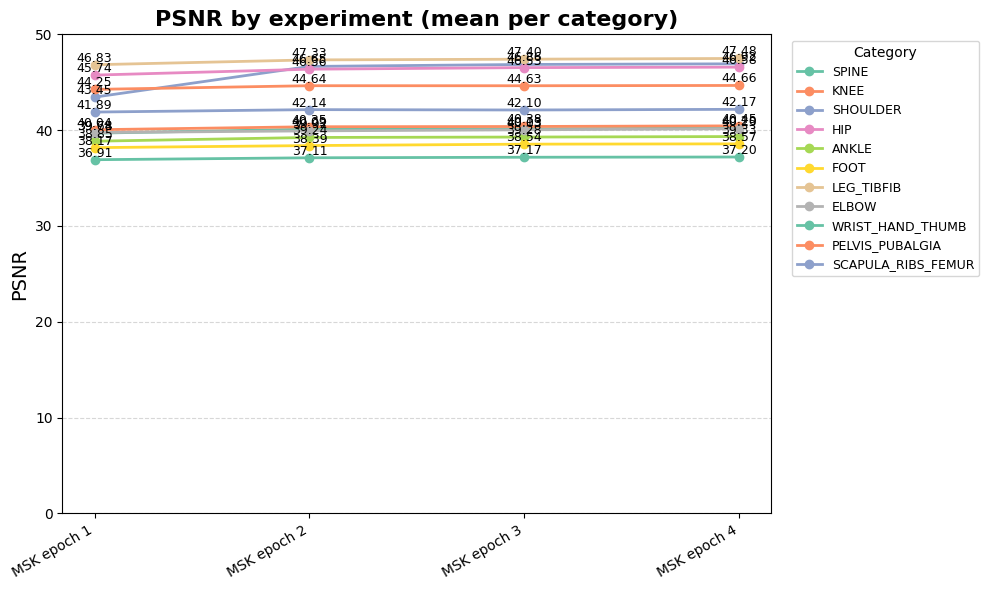

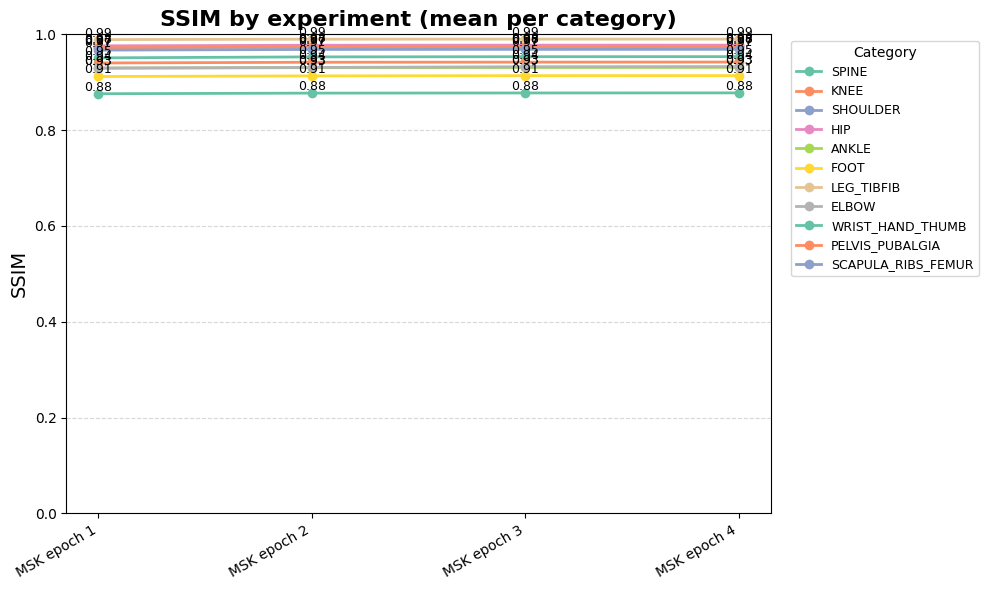


Overall averages by experiment (all categories):
              PSNR    SSIM
experiment                
MSK epoch 1  40.82  0.9519
MSK epoch 2  41.63  0.9535
MSK epoch 3  41.70  0.9538
MSK epoch 4  41.77  0.9540


In [6]:
import os, json, h5py, xml.dom.minidom as minidom
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- CONFIG: set these ----------
data_dir = "../../../../../data/datasets/msk_mri_h5/varnet_msk_dataset2/multicoil_test"
experiments = {
    "MSK epoch 1": "./outputs/finetune_fastmri-msk/msk_casc8_acc4_15/metrics.json",
    "MSK epoch 2": "./outputs/finetune_fastmri-msk/msk_casc8_acc4_16/metrics.json",
    "MSK epoch 3": "./outputs/finetune_fastmri-msk/msk_casc8_acc4_17/metrics.json",
    "MSK epoch 4": "./outputs/finetune_fastmri-msk/msk_casc8_acc4/metrics.json",
}
# --------------------------------------

scan_categories = {
    "SPINE": {"includes": ["L-SPINE","LSPINE","L SPINE","C-SPINE","CSPINE","C SPINE","T-SPINE","T SPINE",
                             "AX T2 T-SP","AX T2 T-SP WARP"]},
    "KNEE": {"includes": ["LT KNEE","RT KNEE"]},
    "SHOULDER": {"includes": ["LT SHOULDER","RT SHOULDER"]},
    "HIP": {"includes": ["LT HIP","RT HIP"]},
    "ANKLE": {"includes": ["LT ANKLE","RT ANKLE"]},
    "FOOT": {"includes": ["LT FOOT","RT FOOT"]},
    "LEG_TIBFIB": {"includes": ["LT LEG","RT TIB-FIB"]},
    "ELBOW": {"includes": ["LT ELBOW","RT ELBOW"]},
    "WRIST_HAND_THUMB": {"includes": ["LT WRIST","RT WRIST","LT THUMB","RT THUMB","RT HAND","WRIST RT"]},
    "PELVIS_PUBALGIA": {"includes": ["PELVIS","ATH PUBALGIA"]},
    "SCAPULA_RIBS_FEMUR": {"includes": ["RT SCAPULA","RIBS","LT FEMUR"]},
}

# Cache file metadata to avoid repeatedly parsing H5 headers across experiments
file_info_cache = {}


def parse_header_study_and_patient(h5_path):
    """Return (tStudyDescription, patientID) from ismrmrd_header; None if missing."""
    try:
        with h5py.File(h5_path, "r") as f:
            if "ismrmrd_header" not in f:
                return None, None
            xml_raw = f["ismrmrd_header"][()]
            if isinstance(xml_raw, (bytes, bytearray, np.void)):
                xml_str = bytes(xml_raw).decode(errors="ignore")
            else:
                xml_str = str(xml_raw)
        dom = minidom.parseString(xml_str)

        def _first_text(parent, tag):
            nodes = parent.getElementsByTagName(tag)
            if nodes and nodes[0].firstChild:
                return nodes[0].firstChild.data.strip()
            return None

        study = None
        ups = dom.getElementsByTagName("userParameterString")
        for node in ups:
            name = _first_text(node, "name")
            if name == "tStudyDescription":
                study = _first_text(node, "value")
                break
        if study is None:
            study = _first_text(dom, "studyDescription")

        pid = None
        sub = dom.getElementsByTagName("subjectInformation")
        if sub:
            pid = _first_text(sub[0], "patientID")
        return study, pid
    except Exception:
        return None, None


def categorize(study_desc):
    if not study_desc:
        return None
    s = study_desc.upper()
    for cat, info in scan_categories.items():
        for token in info["includes"]:
            if token in s:
                return cat
    return None


def get_file_info(fname):
    if fname in file_info_cache:
        return file_info_cache[fname]
    h5_path = os.path.join(data_dir, fname)
    study, pid = parse_header_study_and_patient(h5_path)
    cat = categorize(study)
    file_info_cache[fname] = (cat, study, pid)
    return file_info_cache[fname]


# --------- Load all experiments ----------
all_rows = []
unmatched_by_exp = {}
for exp_name, metrics_path in experiments.items():
    if not os.path.exists(metrics_path):
        raise FileNotFoundError(f"Missing metrics.json for {exp_name}: {metrics_path}")
    with open(metrics_path, "r") as f:
        metrics_json = json.load(f)
    per_vol = metrics_json.get("per_volume", {})

    unmatched = []
    for fname, m in per_vol.items():
        cat, study, pid = get_file_info(fname)
        if cat is None:
            unmatched.append((fname, study))
        all_rows.append({
            "experiment": exp_name,
            "file": fname,
            "category": cat,
            "study": study,
            "patientID": pid,
            "PSNR": m.get("PSNR"),
            "SSIM": m.get("SSIM"),
        })
    unmatched_by_exp[exp_name] = unmatched


df = pd.DataFrame(all_rows)
df_matched = df.dropna(subset=["category"])

print("=== Unmatched files by experiment (category could not be determined) ===")
for exp_name, items in unmatched_by_exp.items():
    if not items:
        print(f"- {exp_name}: none")
        continue
    print(f"- {exp_name}: {len(items)} files")
    for fname, study in items[:8]:  # show a few examples so the output stays readable
        print(f"    {fname} | tStudyDescription={study}")
    if len(items) > 8:
        print(f"    ... {len(items) - 8} more")

# Assign a color to each possible category for consistent plotting
all_categories = list(scan_categories.keys())
color_list = plt.cm.Set2.colors
color_map = {cat: color_list[i % len(color_list)] for i, cat in enumerate(all_categories)}


def plot_metric_lines(metric_name):
    exp_names = list(experiments.keys())
    plt.figure(figsize=(10, 6))
    for cat in all_categories:
        series = []
        for exp_name in exp_names:
            vals = df_matched.loc[(df_matched["experiment"] == exp_name) & (df_matched["category"] == cat), metric_name]
            series.append(vals.mean() if not vals.empty else np.nan)
        if np.all(np.isnan(series)):
            continue  # skip categories absent in every experiment
        plt.plot(exp_names, series, marker="o", linewidth=2, label=cat, color=color_map.get(cat, None))
        for x, y in zip(exp_names, series):
            if not np.isnan(y):
                plt.text(x, y, f"{y:.2f}", ha="center", va="bottom", fontsize=9)

    plt.ylabel(metric_name, fontsize=14)
    plt.title(f"{metric_name} by experiment (mean per category)", fontsize=16, weight="bold")
    plt.xticks(rotation=30, ha="right")
    plt.ylim(0, 50.0 if metric_name == "PSNR" else 1.0)
    plt.grid(True, axis="y", linestyle="--", alpha=0.5)
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9, title="Category")
    plt.tight_layout()
    plt.show()

for metric in ["PSNR", "SSIM"]:
    plot_metric_lines(metric)

overall = df_matched.groupby("experiment")[["PSNR", "SSIM"]].mean()
print("\nOverall averages by experiment (all categories):")
print(overall.round({"PSNR": 2, "SSIM": 4}))


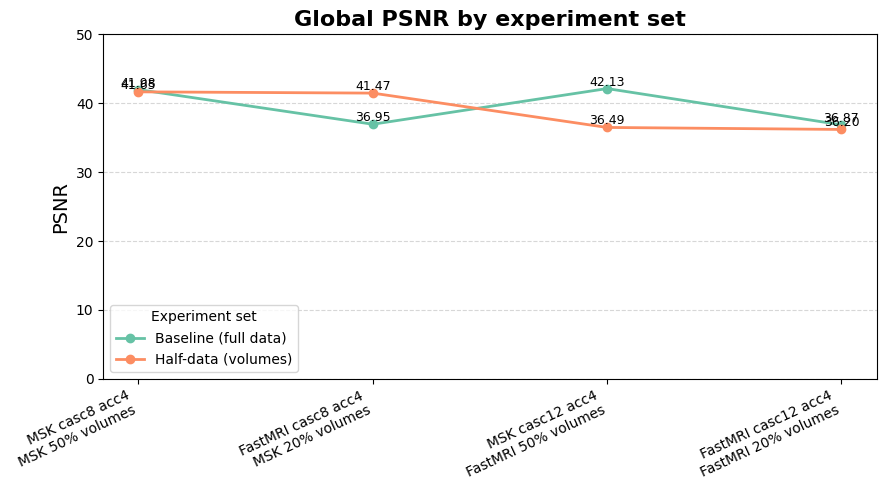


Global PSNR summary:
- Baseline (full data):
    MSK casc8 acc4: mean=41.98, std=5.03
    FastMRI casc8 acc4: mean=36.95, std=3.49
    MSK casc12 acc4: mean=42.13, std=5.01
    FastMRI casc12 acc4: mean=36.87, std=3.43
- Half-data (volumes):
    MSK 50% volumes: mean=41.65, std=4.95
    MSK 20% volumes: mean=41.47, std=4.82
    FastMRI 50% volumes: mean=36.49, std=3.61
    FastMRI 20% volumes: mean=36.20, std=3.59


In [ ]:
# ----- Global PSNR comparison (no categories) -----
# Two experiment sets → two lines; four x positions shared
experiments = {
    "MSK epoch 1": "./outputs/finetune_fastmri-msk/msk_casc8_acc4_15/metrics.json",
    "MSK epoch 2": "./outputs/finetune_fastmri-msk/msk_casc8_acc4_16/metrics.json",
    "MSK epoch 3": "./outputs/finetune_fastmri-msk/msk_casc8_acc4_17/metrics.json",
    "MSK epoch 4": "./outputs/finetune_fastmri-msk/msk_casc8_acc4/metrics.json",
}
global_experiment_sets = {
    "MSK": [
        ("MSK epoch 1", "./outputs/finetune_fastmri-msk/msk_casc8_acc4_15/metrics.json"),
        ("MSK epoch 2", "./outputs/finetune_fastmri-msk/msk_casc8_acc4_16/metrics.json"),
        ("MSK epoch 3", "./outputs/finetune_fastmri-msk/msk_casc8_acc4_17/metrics.json"),
        ("MSK epoch 4", "./outputs/finetune_fastmri-msk/msk_casc8_acc4/metrics.json"),
    ],
    "FastMRI": [
        ("FastMRI epoch 1", "./outputs/finetune_fastmri-msk/fastmri_casc8_acc4_15/metrics.json"),
        ("FastMRI epoch 2", "./outputs/finetune_fastmri-msk/fastmri_casc8_acc4_16/metrics.json"),
        ("FastMRI epoch 3", "./outputs/finetune_fastmri-msk/fastmri_casc8_acc4_17/metrics.json"),
        ("FastMRI epoch 4", "./outputs/finetune_fastmri-msk/fastmri_casc8_acc4/metrics.json"),
    ],
}

psnr_lines = {}
warnings = []
for line_name, experiments in global_experiment_sets.items():
    series = []
    for label, metrics_path in experiments:
        if not os.path.exists(metrics_path):
            warnings.append(f"[warn] Missing metrics for {label}: {metrics_path}")
            series.append((label, None, None))
            continue
        with open(metrics_path, "r") as f:
            metrics = json.load(f)
        psnr = metrics.get("global", {}).get("PSNR", {})
        mean = psnr.get("mean")
        std = psnr.get("std")
        if mean is None:
            warnings.append(f"[warn] No PSNR mean for {label}")
        series.append((label, mean, std if std is not None else 0.0))
    psnr_lines[line_name] = series

if warnings:
    for w in warnings:
        print(w)

# Plot two lines over four shared x positions
plt.figure(figsize=(9, 5))
colors = plt.cm.Set2.colors
num_points = max(len(v) for v in psnr_lines.values()) if psnr_lines else 0
x = np.arange(num_points)

for idx, (line_name, series) in enumerate(psnr_lines.items()):
    means = [m if m is not None else np.nan for _, m, _ in series]
    stds = [s if s is not None else 0.0 for _, m, s in series]
    plt.plot(x, means, marker='o', linewidth=2, label=line_name, color=colors[idx % len(colors)])
    for xi, (label, mean, std) in zip(x, series):
        if mean is not None:
            plt.text(xi, mean, f"{mean:.2f}", ha='center', va='bottom', fontsize=9)

# Build combined x tick labels if both lines share length
labels0 = list(psnr_lines.values())[0] if psnr_lines else []
labels1 = list(psnr_lines.values())[1] if len(psnr_lines) > 1 else []
if labels0 and labels1 and len(labels0) == len(labels1):
    tick_labels = [f"{a[0]}\n{b[0]}" for a, b in zip(labels0, labels1)]
else:
    tick_labels = [lbl for lbl, _, _ in labels0] if labels0 else [str(i+1) for i in range(num_points)]

plt.xticks(x, tick_labels, rotation=25, ha='right')
plt.ylabel('PSNR', fontsize=14)
plt.title('Global PSNR by experiment set', fontsize=16, weight='bold')
plt.ylim(0, 50)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Experiment set')
plt.tight_layout()
plt.show()

print("\nGlobal PSNR summary:")
for line_name, series in psnr_lines.items():
    print(f"- {line_name}:")
    for label, mean, std in series:
        if mean is None:
            print(f"    {label}: missing")
        else:
            std_val = std if std is not None else 0.0
            print(f"    {label}: mean={mean:.2f}, std={std_val:.2f}")
